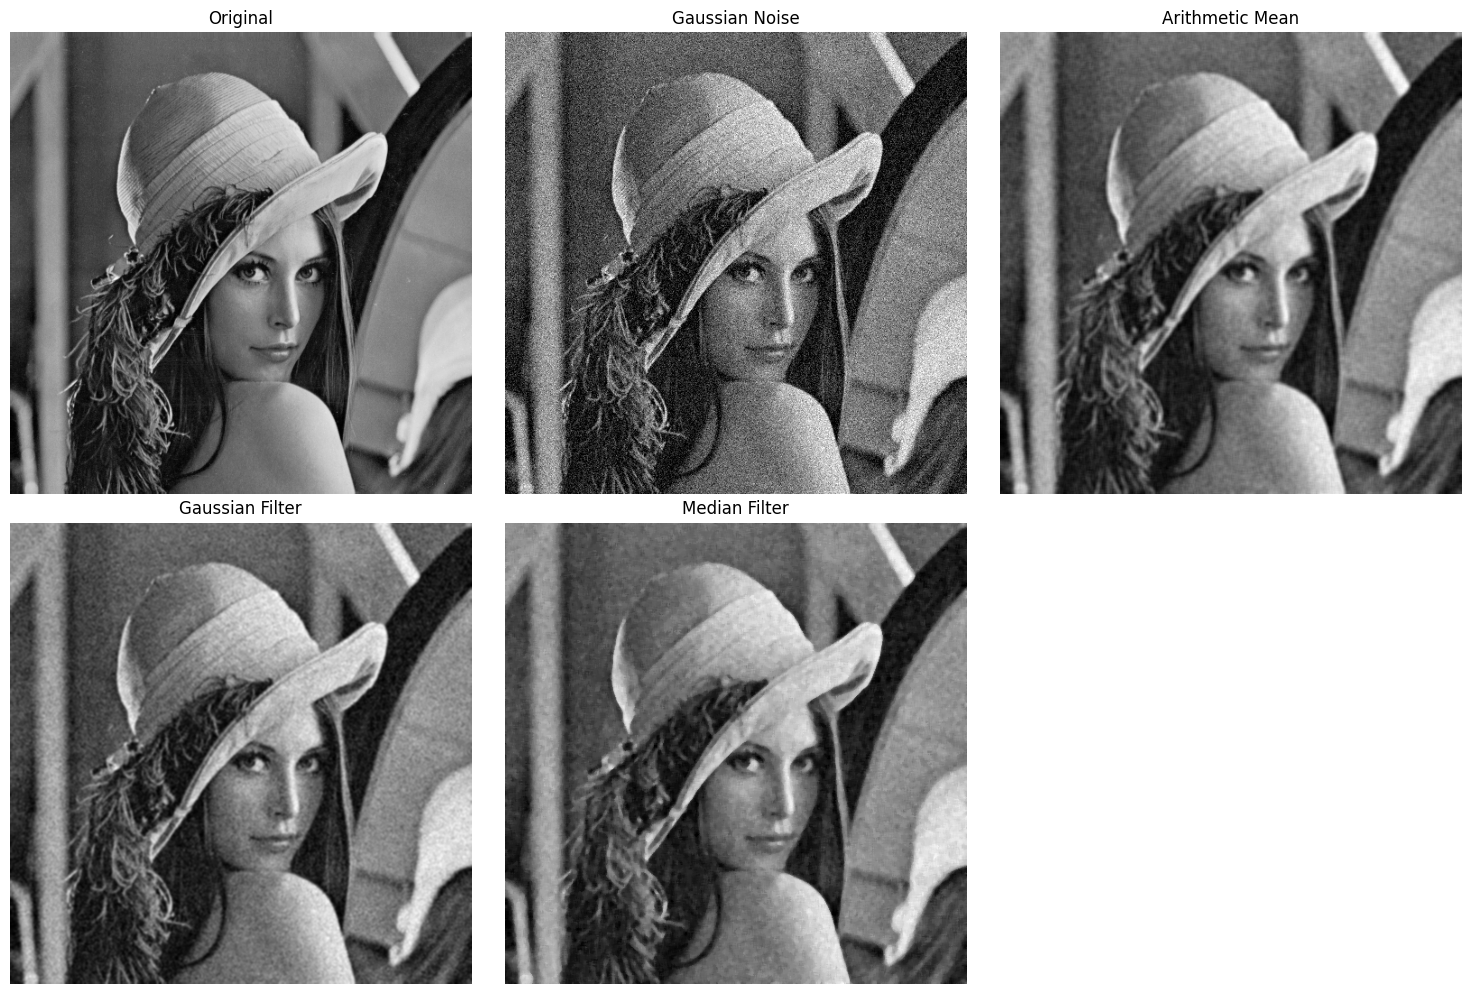

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def add_gaussian_noise(image, mean=0, var=0.01):
    """
    产生高斯噪声并叠加到图像上
    mean: 均值
    var: 方差 (对应 sigma^2)
    """
    image = image.astype(np.float64) / 255.0  # 归一化到 [0, 1]
    sigma = var ** 0.5
    # 生成高斯分布随机数，尺寸与原图一致
    gauss = np.random.normal(mean, sigma, image.shape)
    # 叠加噪声
    noisy = image + gauss
    # 裁剪并恢复到 [0, 255]
    noisy = np.clip(noisy, 0, 1)
    return (noisy * 255).astype(np.uint8)

# 读取原图
img = cv2.imread('lena.bmp', 0)

# 产生噪声图像 (均值 0, 方差 0.01)
noisy_img = add_gaussian_noise(img, mean=0, var=0.01)

# 多种滤波器恢复
# (a) 算术平均滤波 
blur_arithmetic = cv2.blur(noisy_img, (5, 5))

# (b) 高斯滤波 
blur_gaussian = cv2.GaussianBlur(noisy_img, (5, 5), 0)

# (c) 中值滤波 
blur_median = cv2.medianBlur(noisy_img, 5)

# 显示结果
titles = ['Original', 'Gaussian Noise', 'Arithmetic Mean', 'Gaussian Filter', 'Median Filter']
images = [img, noisy_img, blur_arithmetic, blur_gaussian, blur_median]

plt.figure(figsize=(15, 10))
for i in range(5):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

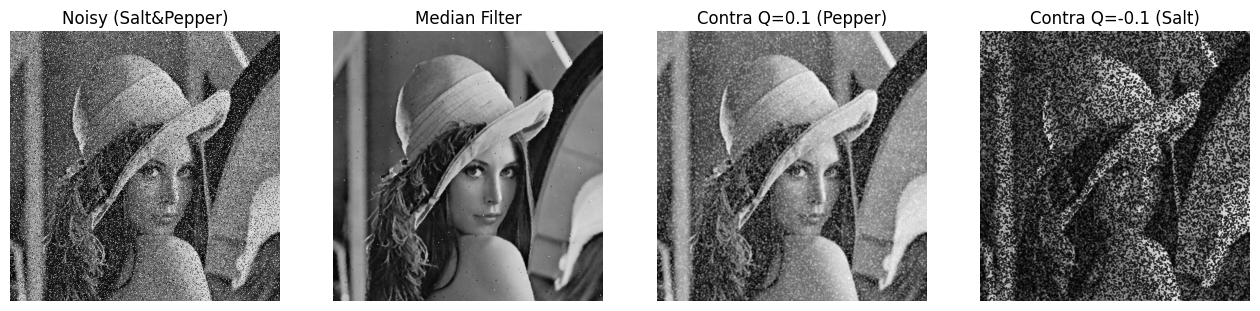

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # 忽略除零警告

def add_salt_and_pepper(image, density=0.1):
    output = np.copy(image)
    # 盐噪声 (白色)
    num_salt = np.ceil(density * image.size)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    output[tuple(coords)] = 255
    # 椒噪声 (黑色)
    num_pepper = np.ceil(density * image.size)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    output[tuple(coords)] = 0
    return output

def contra_harmonic_mean(img, size, Q):
    img = img.astype(float)
    # 避免 0 值导致 power 运算出现除零问题，将 0 替换为极小值
    img_safe = np.where(img == 0, 1e-10, img)

    # 计算分子：g^(Q+1)
    num = np.power(img_safe, Q + 1)
    # 计算分母：g^Q
    den = np.power(img_safe, Q)

    # 使用 cv2.boxFilter 进行窗口内累加 (等同于求和)
    kernel = np.ones((size, size))
    num_sum = cv2.filter2D(num, -1, kernel)
    den_sum = cv2.filter2D(den, -1, kernel)

    # 避免除以 0
    res = num_sum / (den_sum + 1e-8)
    return np.clip(res, 0, 255).astype(np.uint8)

# 读取原图并添加噪声
img = cv2.imread('lena.bmp', 0)
noisy_img = add_salt_and_pepper(img, density=0.1)

# 各种滤波器恢复
# (a) 中值滤波 - 处理椒盐噪声的最佳选手
median_res = cv2.medianBlur(noisy_img, 3)

# (b) 反谐波均值 Q = 1.5 (针对椒噪声/黑点)
contra_pos = contra_harmonic_mean(noisy_img, 3, 0.1)

# (c) 反谐波均值 Q = -1.5 (针对盐噪声/白点)
contra_neg = contra_harmonic_mean(noisy_img, 3, -0.1)

# 结果显示
titles = ['Noisy (Salt&Pepper)', 'Median Filter', 'Contra Q=0.1 (Pepper)', 'Contra Q=-0.1 (Salt)']
images = [noisy_img, median_res, contra_pos, contra_neg]

plt.figure(figsize=(16, 4))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()

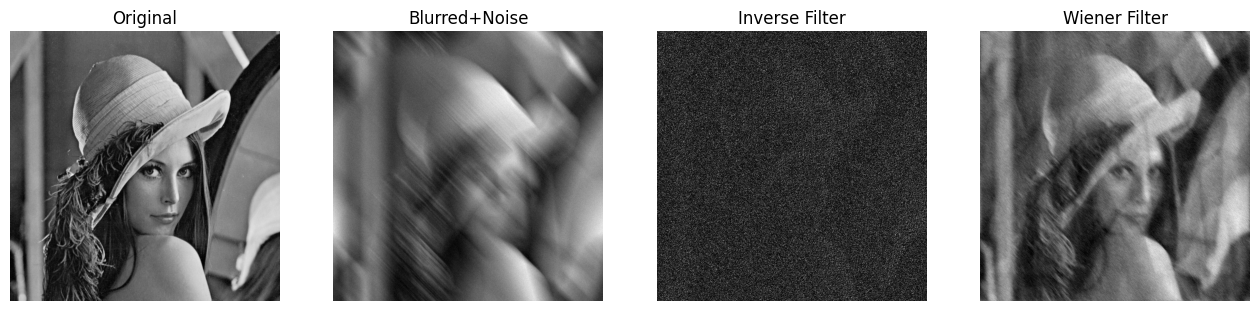

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def motion_blur_h(M, N, a=0.1, b=0.1, T=1):
    u = np.arange(M) - M // 2
    v = np.arange(N) - N // 2
    U, V = np.meshgrid(u, v, indexing='ij')
    
    # 计算公式中的中间项
    term = np.pi * (U * a + V * b)
    # 避免除以 0
    H = T / (term + 1e-8) * np.sin(term + 1e-8) * np.exp(-1j * term)
    return H

# 读取原图
img = cv2.imread('lena.bmp', 0).astype(float)
M, N = img.shape

# 模拟退化过程
F = np.fft.fftshift(np.fft.fft2(img))
H = motion_blur_h(M, N, a=0.1, b=0.1, T=1) # a=b=0.1 对应 45度方向 
G = F * H
blurred_img = np.abs(np.fft.ifft2(np.fft.ifftshift(G)))

# 添加高斯噪声 (方差=10 pixels)
noise = np.random.normal(0, np.sqrt(10), (M, N))
noisy_blurred = blurred_img + noise

# 图像复原
G_noisy = np.fft.fftshift(np.fft.fft2(noisy_blurred))

# (d) 方案 A: 简单逆滤波 
F_inverse = G_noisy / (H + 1e-2) # 加 1e-2 防止除以 0
restored_inv = np.abs(np.fft.ifft2(np.fft.ifftshift(F_inverse)))

# (d) 方案 B: 维纳滤波 
K = 0.01
W = (np.abs(H)**2) / (np.abs(H)**2 + K) / (H + 1e-8)
F_wiener = G_noisy * W
restored_wiener = np.abs(np.fft.ifft2(np.fft.ifftshift(F_wiener)))

# 展示结果
titles = ['Original', 'Blurred+Noise', 'Inverse Filter', 'Wiener Filter']
images = [img, noisy_blurred, restored_inv, restored_wiener]

plt.figure(figsize=(16, 8))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()